In [1]:
!jupyter nbconvert --to script week1_OCR_pipeline_functions.ipynb

[NbConvertApp] WARNING | pattern 'week1_OCR_pipeline_functions.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=Tr

In [2]:
pip install pytesseract pdf2image opencv-python pillow

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 1 — Add Real OCR Functions

Replace dummy function with:


In [4]:
import pytesseract
import cv2
from pdf2image import convert_from_path
import re
import numpy as np

# Convert PDF → Images
def pdf_to_images(pdf_path):
    images = convert_from_path(pdf_path)
    return images


# Preprocess Image
def preprocess_image(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return gray


# Extract Text using OCR
def extract_text_from_images(images):

    text = ""

    for img in images:

        img_cv = cv2.cvtColor(
            np.array(img),
            cv2.COLOR_RGB2BGR
        )

        processed = preprocess_image(img_cv)

        extracted = pytesseract.image_to_string(processed)

        text += extracted

    return text


# Clean Text
def clean_text(text):

    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [5]:
!apt-get install poppler-utils

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


# Step 2 — Test Real OCR

In [6]:
pdf_path = "/content/drive/MyDrive/infosys prompt certificate.pdf"

# Call functions directly from the global scope as they were defined in A4mZ7OPmy15x
images = pdf_to_images(pdf_path)

text = extract_text_from_images(images)

cleaned = clean_text(text)

print(cleaned[:500])

Infosys Navigate your next COURSE COMPLETION CERTIFICATE The certificate is awarded to Anshu Arora for successfully completing the course Prompt Engineering on June 29, 2025 Aaa Thirumala Arohi Executive Vice President and Global Head Education, Training & Assessment (ETA) Infosys Limited


# Step 3 — Save Clean Text

In [7]:
with open("cleaned_text.txt", "w") as f:
    f.write(cleaned)

### Text Extraction Performance Visualization

This visualization compares the length of the raw extracted text with the length of the text after cleaning. This helps to understand how much the cleaning process modifies the extracted content, often by removing extra spaces, newlines, and other artifacts.

Raw Extracted Text Length: 303 characters
Cleaned Text Length: 289 characters


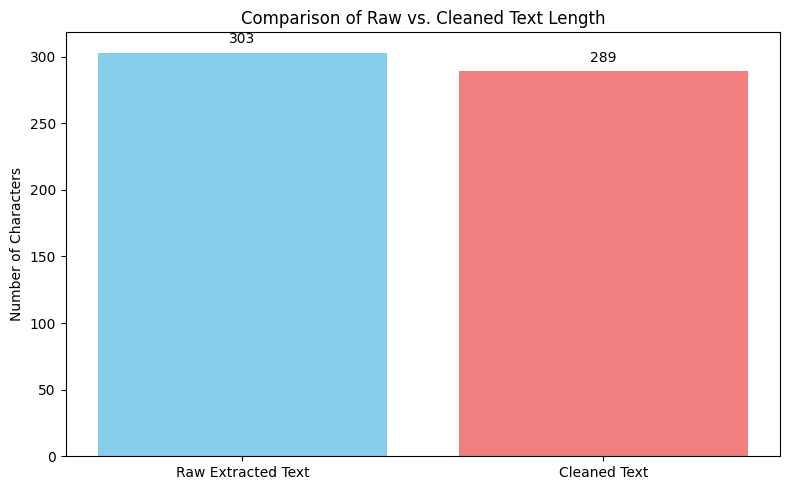

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate the length of the raw and cleaned text
raw_text_len = len(text)
cleaned_text_len = len(cleaned)

# Create a DataFrame for plotting
data = {
    'Text Type': ['Raw Extracted Text', 'Cleaned Text'],
    'Length (Characters)': [raw_text_len, cleaned_text_len]
}
df_performance = pd.DataFrame(data)

# Display the lengths
print(f"Raw Extracted Text Length: {raw_text_len} characters")
print(f"Cleaned Text Length: {cleaned_text_len} characters")

# Create the bar chart
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(df_performance['Text Type'], df_performance['Length (Characters)'], color=['skyblue', 'lightcoral'])
ax.set_title('Comparison of Raw vs. Cleaned Text Length')
ax.set_ylabel('Number of Characters')
ax.set_ylim(bottom=0)

for i, row in df_performance.iterrows():
    ax.text(row['Text Type'], row['Length (Characters)'] + 5, f"{row['Length (Characters)']}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [9]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

/tmp/ipykernel_6578/4246650639.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Word', y='Frequency', data=df_word_freq, palette='viridis')


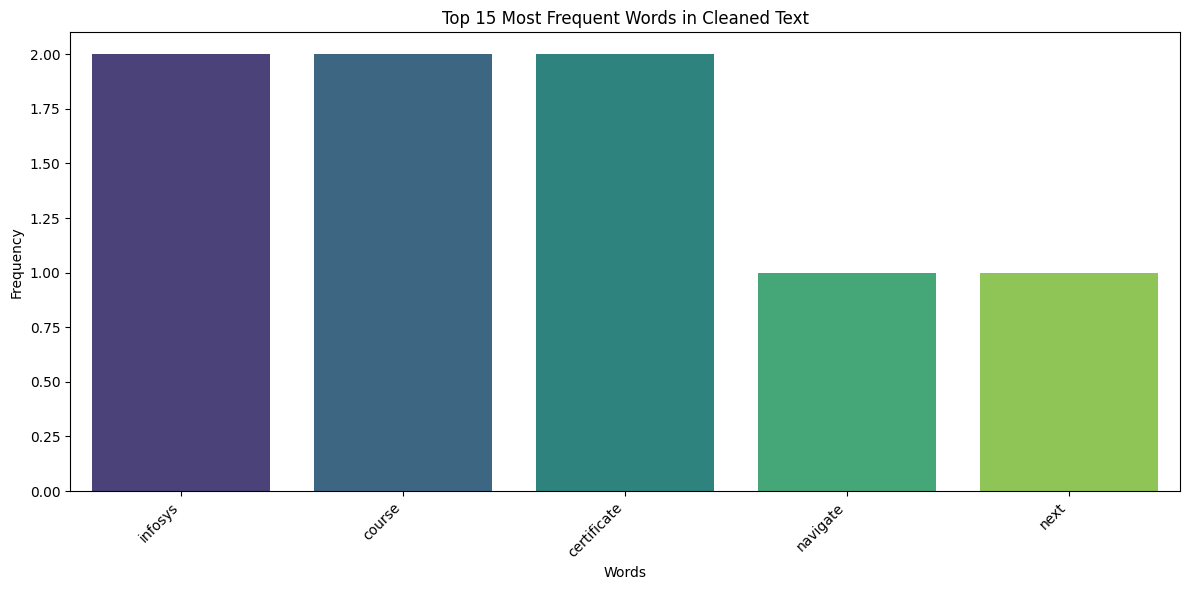

In [10]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Tokenize the cleaned text
words = word_tokenize(cleaned.lower()) # Convert to lowercase for consistent counting

# Remove stop words and non-alphabetic tokens
stop_words = set(stopwords.words('english'))
filtered_words = [word for word in words if word.isalpha() and word not in stop_words]

# Count word frequencies
word_counts = Counter(filtered_words)

# Get the most common words
most_common_words = word_counts.most_common(5) # Top 15 words

# Create a DataFrame for plotting
df_word_freq = pd.DataFrame(most_common_words, columns=['Word', 'Frequency'])

# Plot the word frequencies
plt.figure(figsize=(12, 6))
sns.barplot(x='Word', y='Frequency', data=df_word_freq, palette='viridis')
plt.title('Top 15 Most Frequent Words in Cleaned Text')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
# Calculate and print the total character count of the cleaned text
total_character_count = len(cleaned)
print(f"Total character count of the extracted text: {total_character_count}")

Total character count of the extracted text: 289


# Create Labeled NER Dataset

NER needs labeled entities.
NER models learn from labeled examples.

Without labels → no learning.

In [12]:
training_data = [
    ("John lives in Delhi.",
     {"entities": [(0, 4, "PERSON"),
                   (14, 19, "LOCATION")]})
]

# Choose NER Model

Most beginners use:        spaCy

Algorithm used:

 Bidirectional LSTM (BiLSTM)

In [13]:
import spacy
nlp=spacy.blank('en')
ner=nlp.add_pipe('ner')


#Add Entity Labels

In [15]:
ner.add_label("PERSON")
ner.add_label("LOCATION")
ner.add_label("ORGANIZATION")
ner.add_label("DATE")
ner.add_label("TIME")
ner.add_label("MONEY")
ner.add_label("PERCENT")
ner.add_label("QUANTITY")
ner.add_label("ORDINAL")
ner.add_label("CARDINAL")

1

#Train the NER Model:
Training allows model to learn patterns.

In [21]:
import random
optimizer=nlp.begin_training()

for epoch in range(10):
  random.shuffle(training_data)
  for text, annotations in training_data:
    nlp.update

ValueError: [E989] `nlp.update()` was called with two positional arguments. This may be due to a backwards-incompatible change to the format of the training data in spaCy 3.0 onwards. The 'update' function should now be called with a batch of Example objects, instead of `(text, annotation)` tuples. 

#Test the model

In [20]:
docs=nlp("john works at goolge in delhi")
for ent in docs.ents:
  print(ent.text, ent.label_)

#Save the Model

In [19]:
nlp.to_disk("ner_model")